In [1]:
%load_ext autoreload
%autoreload 2

import collections, pandas as pd, matplotlib, matplotlib.pyplot as plt, seaborn as sns
from af2genomics import *

In [2]:
df_models = read_ppi_reselect().query('pdockq > .5').query('interface_plddt > 90')

310,581 raw records
310,572 after discarding non-dimers
211,081 after keeping uniprot_id-s in AF2 single fragment structures
211,079 after naive de-duplication of interaction_id
106,153 with pdockq > .23
24,524 with pdockq > .5


In [3]:
# One entry per "interaction matrix" (dimer models = both; homomer models = 1)
cols_ = ['bait_id', 'bait_ifresid', 'bait_chain', 'interactor_id', 'interaction_id', 'pdockq', 'pdb']
q_ne_ = 'uniprot_id_A != uniprot_id_B'
q_eq_ = 'uniprot_id_A == uniprot_id_B'
df_interactors = pd.concat([
    df_models.query(q_ne_).rename({'uniprot_id_A': 'bait_id', 'residues1': 'bait_ifresid', 'uniprot_id_B': 'interactor_id', 'chain1': 'bait_chain'}, axis=1)[cols_],
    df_models.query(q_eq_).rename({'uniprot_id_A': 'bait_id', 'residues1': 'bait_ifresid', 'uniprot_id_B': 'interactor_id', 'chain1': 'bait_chain'}, axis=1)[cols_],
    df_models.query(q_ne_).rename({'uniprot_id_B': 'bait_id', 'residues2': 'bait_ifresid', 'uniprot_id_A': 'interactor_id', 'chain2': 'bait_chain'}, axis=1)[cols_],
], axis=0)
df_interactors

,bait_id,bait_ifresid,bait_chain,interactor_id,interaction_id,pdockq,pdb
82,O75506,"16,17,20,23,24,27,28,30,31,32,34,35,38,41,42,4...",A,Q8WUW1,O75506_Q8WUW1,0.58,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
129,A8MWD9,"14,21,22,25,32,33,34,35,37,39,40,41,43,47,56,5...",A,P62306,A8MWD9_P62306,0.56,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
163,P62308,"10,13,21,22,23,25,27,32,33,34,35,37,39,40,41,4...",A,Q9Y4Y9,P62308_Q9Y4Y9,0.60,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
164,A8MWD9,"10,13,14,21,22,23,25,27,32,33,34,35,37,39,40,4...",A,P62304,A8MWD9_P62304,0.63,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
172,P62304,"12,13,14,15,16,17,18,20,21,23,24,34,35,36,39,4...",A,P62308,P62304_P62308,0.64,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
...,...,...,...,...,...,...,...
207468,Q7Z6B7,"5,6,7,8,9,10,13,16,17,20,21,24,27,30,31,34,37,...",B,O75044,O75044_Q7Z6B7,0.73,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
207673,P24928,"876,878,880,883,884,885,886,887,888,889,890,89...",B,P19388,P19388_P24928,0.72,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210128,Q9UFF9,"21,25,28,134,135,137,138,141,142,143,144,146,1...",B,A5YKK6,A5YKK6_Q9UFF9,0.58,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...
210416,Q9C0J8,"51,53,56,57,58,59,60,61,62,63,64,65,66,67,68,7...",B,Q10570,Q10570_Q9C0J8,0.73,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...


In [4]:
# df_interfaces: summary of interactions per "bait" protein
df_interfaces = df_interactors.groupby('bait_id').agg(
    interactor_id = ('interactor_id', lambda interactor_id: ','.join(sorted(interactor_id))),
    n_interactors = ('interactor_id', lambda x: len(x)),
    resid_counts = ('bait_ifresid', lambda x: collections.Counter(xii for xi in x for xii in parse_resid(xi)))
).reset_index().sort_values('n_interactors', ascending=False)
printlen(df_interfaces)
df_nresid_ = read_structures().query('frag_id == "F1"')[['uniprot_id', 'n_resid']]
df_interfaces = df_interfaces.merge(df_nresid_, left_on='bait_id', right_on='uniprot_id').drop('uniprot_id', axis=1)
printlen(df_interfaces)
df_interfaces = df_interfaces.sort_values('n_interactors', ascending=False).query('n_interactors > 5').sample(n=10, random_state=RANDOM_SEED)
df_interfaces

2,874
2,874


,bait_id,interactor_id,n_interactors,resid_counts,n_resid
124,P09210,"O15217,P08263,P08684,P46439,Q16772,Q7RTV2",6,"{131: 5, 132: 5, 135: 5, 136: 5, 138: 3, 139: ...",222
5,P61077,"O43567,O95376,P22681,P78317,Q13064,Q13191,Q6ZN...",18,"{96: 16, 1: 16, 5: 16, 8: 16, 9: 13, 12: 10, 9...",147
69,P39023,"P20226,P26373,P46779,Q00577,Q16777,Q5JNZ5,Q8IU...",8,"{6: 2, 232: 1, 236: 2, 237: 1, 238: 1, 239: 3,...",403
33,Q96BH1,"P49459,P51668,P51965,P61077,P61086,P61088,P628...",11,"{257: 11, 258: 5, 260: 4, 134: 4, 136: 11, 137...",459
35,P17535,"P01100,P05412,P15407,P15408,P18847,P53539,P535...",10,"{289: 8, 290: 5, 292: 9, 293: 10, 296: 10, 297...",347
11,Q9HAV0,"O14610,O60262,O95837,P08754,P50150,P50151,P597...",15,"{256: 12, 257: 12, 258: 12, 3: 10, 4: 12, 261:...",340
90,Q9ULX9,"O15525,O60675,P05412,P18847,Q6ICC9,Q9NR55,Q9ULX9",7,"{75: 4, 76: 7, 79: 7, 80: 7, 82: 7, 83: 7, 86:...",164
92,Q9Y333,"O95777,P14678,P62306,P62308,P62310,P63162,Q9BRA0",7,"{1: 1, 2: 6, 3: 6, 6: 6, 7: 6, 18: 6, 20: 6, 2...",95
108,P19387,"P0DPB6,P30876,P52435,P62875,Q9H1A7,Q9H9Y6,Q9NW08",7,"{130: 1, 131: 1, 144: 1, 17: 1, 145: 1, 146: 1...",275
32,P62306,"A8MWD9,O95777,P62304,P62310,P62314,P62316,P623...",11,"{10: 3, 11: 3, 12: 3, 13: 1, 14: 1, 15: 1, 17:...",86


P62873 bait uniprot id
16 interaction models sharing the bait
340 number of bait residues
(16, 340) shape matrix dimensions
57970 non-zero entries in residue matrix
1    12
2     4
Name: labels, dtype: int64
delete all
load ~/work-euler/23.12.06_ppi_reselect/af2-models-split/P62873/P62873_Q9P2W3.pdb
color gray, P62873_Q9P2W3 & chain A
color 0x1f77b4, P62873_Q9P2W3 & chain B
load ~/work-euler/23.12.06_ppi_reselect/af2-models-split/P04899/P04899_P62873.pdb
align P04899_P62873 & chain B, P62873_Q9P2W3 & chain A
color 0xff7f0e, P04899_P62873 & chain A
color gray, P04899_P62873 & chain B


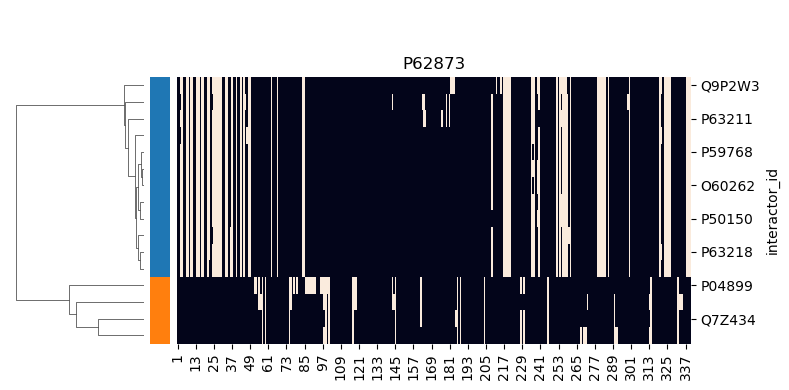

In [5]:
# Cluster single example
uniprot_id_bait = 'P62873'
bait_ = SharedInterfaceAnalysis(df_interactors.query('bait_id == @uniprot_id_bait'))
bait_.linkage(criterion='distance', t=.9)
bait_.clustermap()#'P62873.svg')
bait_.to_pymol()

In [6]:
# Cluster subset, plot distribution
def nclusters_(i, r):
    uniprot_id_bait = r.bait_id
    #pse_ = workpath(f'24.01.22_interface_clusters/{uniprot_id_bait}.pse')
    #svg_ = workpath(f'24.01.22_interface_clusters/{uniprot_id_bait}.svg')
    pse_ = f'interface_clusters/{uniprot_id_bait}.pse'
    svg_ = f'interface_clusters/{uniprot_id_bait}.svg'
    bait_ = SharedInterfaceAnalysis(df_interactors.query('bait_id == @uniprot_id_bait'))
    bait_.linkage(criterion='distance', t=.9)
    bait_.clustermap(fname=svg_)
    bait_.to_pymol(fname=pse_)
    return len(bait_.df_interactors['labels'].value_counts())

df_interfaces['nclusters'] = [ nclusters_(i, r) for i, r in df_interfaces.iterrows() ]

P09210 bait uniprot id
6 interaction models sharing the bait
222 number of bait residues
(6, 222) shape matrix dimensions
24753 non-zero entries in residue matrix
1    5
2    1
Name: labels, dtype: int64
P61077 bait uniprot id
18 interaction models sharing the bait
147 number of bait residues
(18, 147) shape matrix dimensions
10878 non-zero entries in residue matrix
1    16
3     1
2     1
Name: labels, dtype: int64
P39023 bait uniprot id
8 interaction models sharing the bait
403 number of bait residues
(8, 403) shape matrix dimensions
81406 non-zero entries in residue matrix
1    3
3    3
2    1
4    1
Name: labels, dtype: int64
Q96BH1 bait uniprot id
11 interaction models sharing the bait
459 number of bait residues
(11, 459) shape matrix dimensions
105570 non-zero entries in residue matrix
1    11
Name: labels, dtype: int64
P17535 bait uniprot id
10 interaction models sharing the bait
347 number of bait residues
(10, 347) shape matrix dimensions
60378 non-zero entries in residue mat

In [9]:
sns.histplot(data=df_interfaces, x='nclusters', discrete=True, stat='percent', shrink=.8)
plt.title('Clustering high-confidence interfaces by Jaccard index')
plt.gca().set_xlabel('Number of distinct interface clusters per protein')
plt.savefig('interface_clusters.svg', bbox_inches='tight', transparent=True)